# STFT-CNN Sleep Stage Classification
**架构与 TimesNet notebook 完全对齐**，相同数据切分 / 相同患者分组 / 相同评估图表。

用途：作为与 TimesNet 的**频域对比实验**，输入同一套 `.npy` 文件，输出可直接比较的 Accuracy / Macro-F1 / Confusion Matrix / Hypnogram。

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3080 Laptop GPU


# 1. Pre-process

Import & Load data

In [2]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib.pyplot as plt
import seaborn as sns
import time, copy
from collections import Counter
from scipy import signal as scipy_signal
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, cohen_kappa_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── 复现 TimesNet notebook 的同一个起始患者 ──────────────────────────────────
df = pd.read_csv("dataset/S025_whole_df.csv")
df.head()


,TIMESTAMP,BVP,ACC_X,ACC_Y,ACC_Z,TEMP,EDA,HR,IBI,Sleep_Stage,Obstructive_Apnea,Central_Apnea,Hypopnea,Multiple_Events
0,0.000000,140.76,-40.0,7.0,50.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN
1,0.015625,135.32,-40.0,7.0,50.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN
2,0.031250,130.88,-41.0,7.0,49.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN
3,0.046875,118.15,-41.0,7.0,49.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN
4,0.062500,92.38,-41.0,8.0,50.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN


Select features & check missing values

In [3]:
features  = ['BVP', 'IBI', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR']
label_col = 'Sleep_Stage'

stage_counts = df['Sleep_Stage'].value_counts(dropna=False)
print(stage_counts)

missing_before = df[features].isna().sum().sum()
print(f"Missing Before: {missing_before}")


Sleep_Stage
N2    858240
W     412801
P     406592
R     240000
N1     74880
Name: count, dtype: int64
Missing Before: 2488


Fill missing values

In [4]:
df[features] = df[features].interpolate(method='linear', limit_direction='both')
print(f"Missing After: {df[features].isna().sum().sum()}")

Missing After: 0


## STFT 预处理：把每个 1920 点窗口转成时频图

与 TimesNet 的输入维度唯一区别：
- TimesNet 输入 → `(1920, 8)` 原始时序
- STFT 输入 → `(8, 12, 59)` 时频图张量（8通道 × 12频段 × 59时间帧）

**窗口大小、标签切分逻辑与 TimesNet 完全一致（`window_size=1920`）。**

In [5]:
# ============================================================
# STFT 预处理 — 方案B: 快/慢信号差异化 nperseg
#   快信号(BVP/ACC/HR): nperseg=64 (1秒), Δf=1Hz, 保时间分辨率
#   慢信号(IBI/EDA/TEMP): nperseg=1920(整30秒), Δf≈0.0333Hz, 保频率分辨率
#     — 单帧频谱, 再在时间轴广播到和快信号一致的帧数
# ============================================================
FEATURE_NAMES = ['BVP', 'IBI', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR']

FAST_CHANNELS = {'BVP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR'}
SLOW_CHANNELS = {'IBI', 'EDA', 'TEMP'}

FAST_NPERSEG, FAST_NOVERLAP = 64, 32     # Δf = 64/64   = 1.0000 Hz/bin
SLOW_NPERSEG, SLOW_NOVERLAP = 1920, 0    # Δf = 64/1920 = 0.0333 Hz/bin

# 保留 bin 数按各通道真实有效频段换算，不再是拍脑袋整数Hz
CHANNEL_KEEP_BINS = {
    'BVP':   12,   # 0~12 Hz   (心率基频+若干谐波)
    'ACC_X': 12,
    'ACC_Y': 12,
    'ACC_Z': 12,
    'HR':     8,   # 0~8 Hz
    'IBI':   12,   # 0~0.40 Hz (HRV LF 0.04-0.15 + HF 0.15-0.4, 完整覆盖)
    'EDA':   15,   # 0~0.50 Hz (SCR 主要能量集中区)
    'TEMP':   4,   # 0~0.13 Hz (皮肤温慢变化, 30秒内基本只有趋势)
}
MAX_BINS = max(CHANNEL_KEEP_BINS.values())   # 15 (原来是12, 变了)


def compute_stft_window(window_2d, fs=64):
    """
    单窗口 (1920, 8) → STFT tensor (8, MAX_BINS, T)
    """
    n_channels = window_2d.shape[1]

    # 先用快信号参数算一次，确定目标帧数 T（只和 nperseg/noverlap/长度有关，和数值无关）
    _, _, Zxx_ref = scipy_signal.stft(
        window_2d[:, 0].astype(np.float64), fs=fs, window='hamming',
        nperseg=FAST_NPERSEG, noverlap=FAST_NOVERLAP, boundary='zeros'
    )
    T = Zxx_ref.shape[1]

    spectrograms = []
    for c in range(n_channels):
        name = FEATURE_NAMES[c]
        keep = CHANNEL_KEEP_BINS[name]
        sig  = window_2d[:, c].astype(np.float64)

        if name in SLOW_CHANNELS:
            # 整窗一次 FFT，只有 1 帧，频率分辨率细
            _, _, Zxx = scipy_signal.stft(
                sig, fs=fs, window='hamming',
                nperseg=SLOW_NPERSEG, noverlap=SLOW_NOVERLAP,
                boundary=None, padded=False
            )
            mag     = np.abs(Zxx[:keep, :])            # (keep, 1)
            log_mag = np.log(mag + 1e-8)
            log_mag = np.repeat(log_mag, T, axis=1)     # 广播到 T 帧，对齐快信号时间轴
        else:
            _, _, Zxx = scipy_signal.stft(
                sig, fs=fs, window='hamming',
                nperseg=FAST_NPERSEG, noverlap=FAST_NOVERLAP, boundary='zeros'
            )
            mag     = np.abs(Zxx[:keep, :])             # (keep, T)
            log_mag = np.log(mag + 1e-8)

        if keep < MAX_BINS:
            pad     = np.zeros((MAX_BINS - keep, log_mag.shape[1]))
            log_mag = np.vstack([log_mag, pad])

        spectrograms.append(log_mag.astype(np.float32))

    return np.stack(spectrograms, axis=0)   # (8, MAX_BINS, T)


test_out = compute_stft_window(np.random.randn(1920, 8))
print(f"STFT output shape per window: {test_out.shape}")
# 期望: (8, 15, 61) —— 15是新的MAX_BINS(EDA决定), 之前是12

STFT output shape per window: (8, 15, 61)


In [6]:
# ============================================================
# 训练集统计量归一化 (替代逐窗口 min-max)
# 只用训练集算 mean/std, 测试集套用同一组统计量, 不发生信息泄漏
# ============================================================

def compute_norm_stats(X_train):
    """
    X_train: (N, 8, 12, n_frames) 原始 log-magnitude
    返回 per-channel-per-freqbin 的 mean/std, shape (1, 8, 12, 1)
    对每个通道的每个频段单独归一化, 保留通道间/窗口间的绝对能量差异
    """
    mean = X_train.mean(axis=(0, 3), keepdims=True)   # 沿 样本 和 时间帧 求均值
    std  = X_train.std(axis=(0, 3), keepdims=True)
    std  = np.where(std < 1e-6, 1.0, std)             # 防止除0
    return mean.astype(np.float32), std.astype(np.float32)

def apply_norm(X, mean, std):
    """用给定统计量做 z-score, 测试集也调这个 (传入训练集的 mean/std)"""
    return ((X - mean) / std).astype(np.float32)

Slice data — 与 TimesNet notebook 完全相同的 window_size=1920

In [7]:
window_size = 1920    # 30 秒 @ 64 Hz（与 TimesNet 对齐）

def create_windows_stft(df_in, window_size=1920):
    n_samples = len(df_in) // window_size
    X_list, y_list = [], []

    for i in range(n_samples):
        s, e       = i * window_size, (i + 1) * window_size
        window_df  = df_in.iloc[s:e]
        mode_series = window_df[label_col].mode()
        if mode_series.empty:
            continue
        label = mode_series.iloc[0]
        if str(label).strip() in ['P', 'Missing']:
            continue

        raw_window = window_df[features].values          # (1920, 8)
        stft_tensor = compute_stft_window(raw_window)    # (8, 12, 59)

        X_list.append(stft_tensor)
        y_list.append(label)

    return np.array(X_list), np.array(y_list)

print("Generating STFT windows for S025 (single patient)...")
X, y = create_windows_stft(df)
print(f"X shape: {X.shape}")   # (N, 8, 12, 59)
print(f"y shape: {y.shape}")
print(f"Label sample: {y[:5]}")


Generating STFT windows for S025 (single patient)...
X shape: (825, 8, 15, 61)
y shape: (825,)
Label sample: ['W' 'W' 'W' 'W' 'W']


In [8]:
label_map = {'W': 0, 'N1': 1, 'N2': 2, 'N3': 3, 'R': 4}
y_encoded = np.array([label_map[l] for l in y])
print("Encoded labels:", y_encoded[:5])


Encoded labels: [0 0 0 0 0]


# 2. Single Patient Training

Split & save data

In [9]:
save_dir = './dataset/stft_data_ready/'
os.makedirs(save_dir, exist_ok=True)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp)

norm_mean, norm_std = compute_norm_stats(X_train)
X_train = apply_norm(X_train, norm_mean, norm_std)
X_val   = apply_norm(X_val,   norm_mean, norm_std)
X_test  = apply_norm(X_test,  norm_mean, norm_std)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  y_test:  {y_test.shape}")

np.save(os.path.join(save_dir, 'X_train.npy'), X_train)
np.save(os.path.join(save_dir, 'y_train.npy'), y_train)
np.save(os.path.join(save_dir, 'X_val.npy'),   X_val)
np.save(os.path.join(save_dir, 'y_val.npy'),   y_val)
np.save(os.path.join(save_dir, 'X_test.npy'),  X_test)
np.save(os.path.join(save_dir, 'y_test.npy'),  y_test)
print("Saved.")


X_train: (577, 8, 15, 61)  y_train: (577,)
X_val:   (83, 8, 15, 61)  y_val:   (83,)
X_test:  (165, 8, 15, 61)  y_test:  (165,)
Saved.


Dataset & DataLoader

In [10]:
class STFTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)   # (N, 8, 12, 59)
        self.y = torch.LongTensor(y)

    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

def make_loaders(X_tr, y_tr, X_v, y_v, X_te, y_te, batch_size=32):
    return (
        DataLoader(STFTDataset(X_tr, y_tr), batch_size, shuffle=True),
        DataLoader(STFTDataset(X_v,  y_v),  batch_size, shuffle=False),
        DataLoader(STFTDataset(X_te, y_te), batch_size, shuffle=False),
    )

train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test)
print("DataLoaders ready.")


DataLoaders ready.


## STFT-CNN Model
2D-CNN 处理时频图，结构与 TimesNet 参数量相近（约 300K），保证对比公平。

In [11]:
class STFTSleepNet(nn.Module):
    """
    两层 2D-CNN + AdaptiveAvgPool + 全连接分类头
    输入: (B, 8, 12, 59)
    输出: (B, 5)  → W/N1/N2/N3/R
    """
    def __init__(self, in_channels=8, num_classes=5, dropout=0.3):
        super().__init__()
        self.encoder = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # (B, 32, 6, 29)

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # (B, 64, 3, 14)

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 4)),  # (B, 128, 2, 4) 固定输出
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                  # (B, 1024)
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.encoder(x))

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = STFTSleepNet().to(DEVICE)
total  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device: {DEVICE}")
print(f"Trainable parameters: {total:,}")


Device: cuda
Trainable parameters: 374,309


Weighted Loss — 与 TimesNet notebook 相同的类别不平衡处理

In [12]:
weights = torch.tensor([1.0, 2.0, 0.35, 1.1, 0.9], dtype=torch.float32)
print("[physiological-prior] W/N1/N2/N3/R =", weights.tolist())

weight_tensor = torch.FloatTensor(weights).to(DEVICE)
criterion     = nn.CrossEntropyLoss(weight=weight_tensor)

[physiological-prior] W/N1/N2/N3/R = [1.0, 2.0, 0.3499999940395355, 1.100000023841858, 0.8999999761581421]


Train

In [13]:
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, verbose=True)

EPOCHS   = 50
PATIENCE = 10

best_val_f1  = 0
best_state   = None
patience_cnt = 0
history      = {'train_loss': [], 'val_acc': [], 'val_f1': []}

print("Starting training...")
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    # ── train ────────────────────────────────────────────────
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    # ── validate ─────────────────────────────────────────────
    model.eval()
    preds_v, trues_v = [], []
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            out     = model(X_batch)
            val_loss += criterion(out, y_batch.to(DEVICE)).item()
            preds_v.extend(out.argmax(1).cpu().numpy())
            trues_v.extend(y_batch.numpy())

    val_acc = accuracy_score(trues_v, preds_v)
    val_f1  = f1_score(trues_v, preds_v, average='macro', zero_division=0)
    scheduler.step(val_f1)

    history['train_loss'].append(total_loss / len(train_loader))
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch:3d} | "
          f"Train Loss: {total_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val Macro-F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state  = {k: v.clone() for k, v in model.state_dict().items()}
        patience_cnt = 0
        print(f"  ✓ Best model saved (F1={val_f1:.4f})")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
print(f"\nTraining done in {time.time()-t0:.1f}s")


C:\Users\15810\anaconda3\envs\timesnet\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting training...
Epoch   1 | Train Loss: 1.1284 | Val Loss: 0.8566 | Val Acc: 0.7349 | Val Macro-F1: 0.5531
  ✓ Best model saved (F1=0.5531)
Epoch   2 | Train Loss: 0.8768 | Val Loss: 0.9161 | Val Acc: 0.8072 | Val Macro-F1: 0.6123
  ✓ Best model saved (F1=0.6123)
Epoch   3 | Train Loss: 0.7101 | Val Loss: 0.9672 | Val Acc: 0.8434 | Val Macro-F1: 0.6448
  ✓ Best model saved (F1=0.6448)
Epoch   4 | Train Loss: 0.6897 | Val Loss: 0.6702 | Val Acc: 0.8675 | Val Macro-F1: 0.6850
  ✓ Best model saved (F1=0.6850)
Epoch   5 | Train Loss: 0.6483 | Val Loss: 0.7817 | Val Acc: 0.7831 | Val Macro-F1: 0.5961
Epoch   6 | Train Loss: 0.5978 | Val Loss: 0.6640 | Val Acc: 0.8795 | Val Macro-F1: 0.6827
Epoch   7 | Train Loss: 0.5305 | Val Loss: 0.6277 | Val Acc: 0.8675 | Val Macro-F1: 0.7487
  ✓ Best model saved (F1=0.7487)
Epoch   8 | Train Loss: 0.4643 | Val Loss: 0.4589 | Val Acc: 0.8795 | Val Macro-F1: 0.6847
Epoch   9 | Train Loss: 0.4123 | Val Loss: 0.6705 | Val Acc: 0.8072 | Val Macro-F1: 0.

Training curves

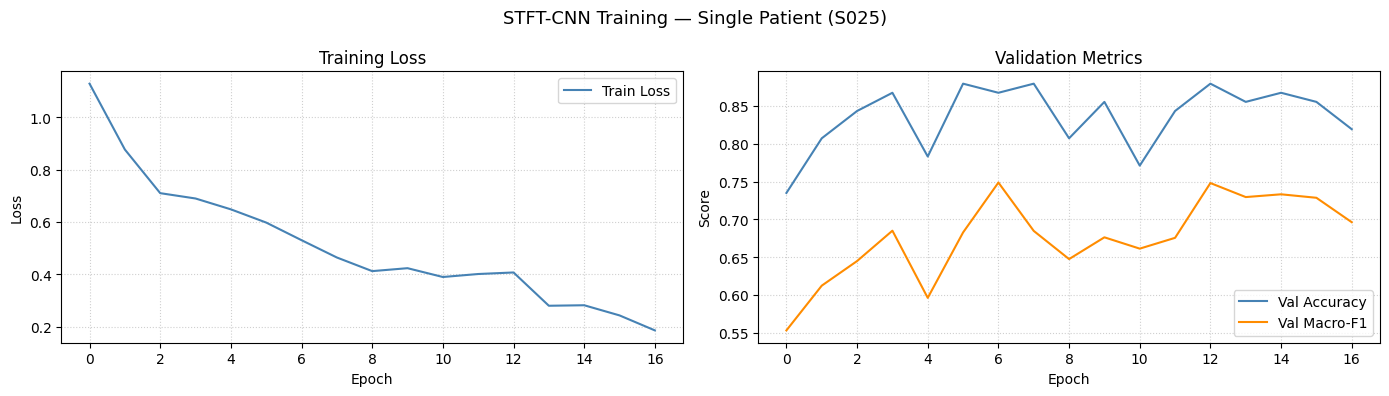

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(history['val_acc'],  label='Val Accuracy',  color='steelblue')
axes[1].plot(history['val_f1'],   label='Val Macro-F1',  color='darkorange')
axes[1].set_title('Validation Metrics')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('STFT-CNN Training — Single Patient (S025)', fontsize=13)
plt.tight_layout()
plt.show()


Graph — Confusion Matrix & Hypnogram

=== Single Patient Test Results ===
Accuracy              : 0.8182
Cohen's Kappa         : 0.7088
Macro-F1 (all 5 cls)  : 0.5391
Macro-F1 (present 4 cls): 0.6739
              precision    recall  f1-score   support

           W       0.79      0.86      0.82        43
          N1       0.14      0.12      0.13         8
          N2       0.88      0.83      0.86        89
          N3       0.00      0.00      0.00         0
           R       0.85      0.92      0.88        25

   micro avg       0.82      0.82      0.82       165
   macro avg       0.53      0.55      0.54       165
weighted avg       0.82      0.82      0.82       165



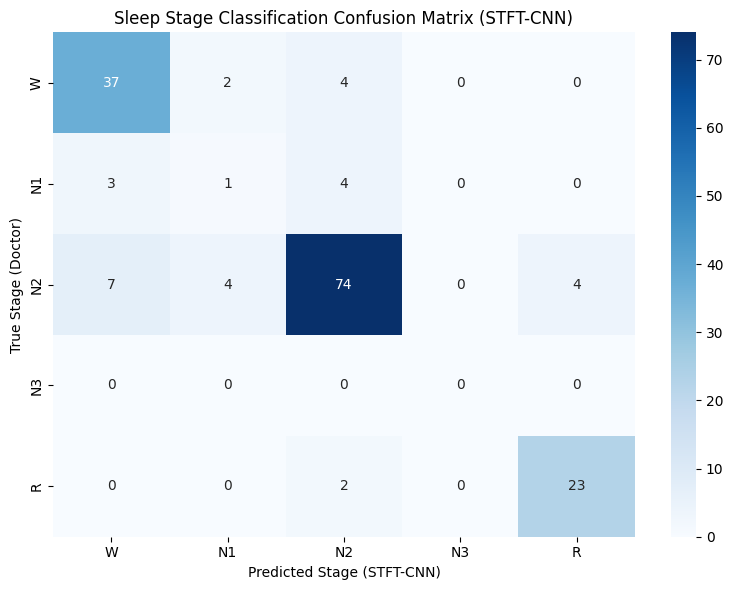

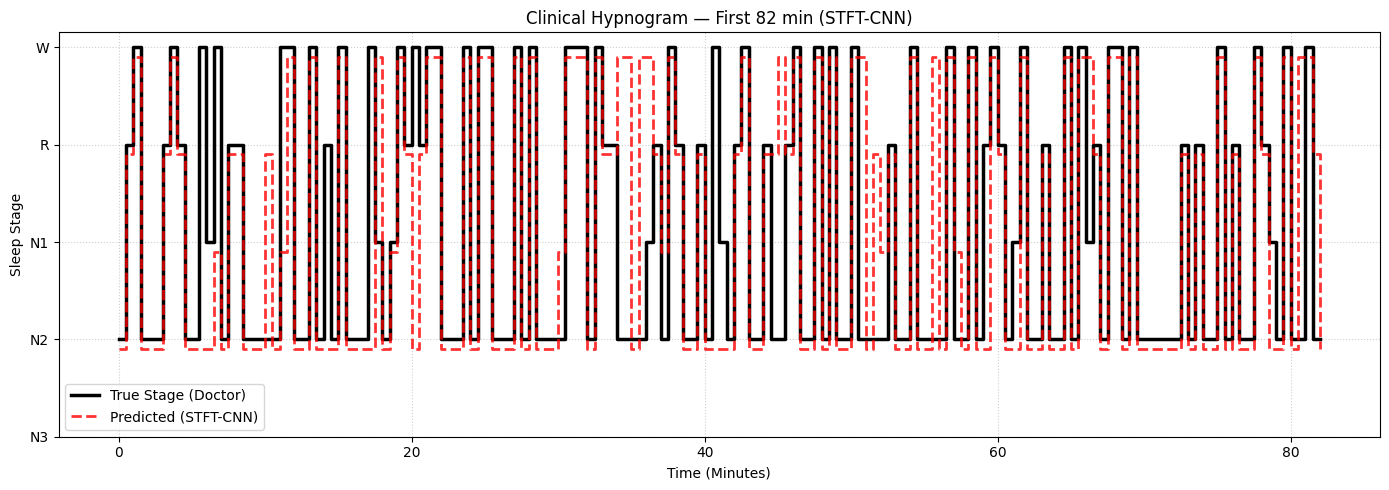

In [15]:
def evaluate_and_plot(model, loader, title_suffix=''):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            out = model(X_batch.to(DEVICE))
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(y_batch.numpy())

    preds, trues = np.array(preds), np.array(trues)
    present      = sorted(np.unique(trues).tolist())
    acc          = accuracy_score(trues, preds)
    kappa        = cohen_kappa_score(trues, preds)
    macro_f1_5   = f1_score(trues, preds, labels=[0,1,2,3,4], average='macro', zero_division=0)
    macro_f1_pre = f1_score(trues, preds, labels=present,     average='macro', zero_division=0)

    print(f"Accuracy              : {acc:.4f}")
    print(f"Cohen's Kappa         : {kappa:.4f}")
    print(f"Macro-F1 (all 5 cls)  : {macro_f1_5:.4f}")
    print(f"Macro-F1 (present {len(present)} cls): {macro_f1_pre:.4f}")

    print(classification_report(trues, preds,
          labels=[0,1,2,3,4],                # ← 修复：强制包含全部5类
          target_names=['W','N1','N2','N3','R'],
          zero_division=0))


    labels = ['W', 'N1', 'N2', 'N3', 'R']

    # Confusion Matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(trues, preds, labels=[0,1,2,3,4])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Sleep Stage Classification Confusion Matrix{title_suffix}')
    plt.xlabel('Predicted Stage (STFT-CNN)')
    plt.ylabel('True Stage (Doctor)')
    plt.tight_layout()
    plt.show()

    # Hypnogram
    clinical_order  = [0, 4, 1, 2, 3]
    clinical_labels = ['W', 'R', 'N1', 'N2', 'N3']
    y_true_c = [-clinical_order.index(v) for v in trues]
    y_pred_c = [-clinical_order.index(v) for v in preds]

    display_length = min(600, len(trues))
    time_axis      = np.arange(display_length) * 0.5  # 每格 30秒 = 0.5分钟

    plt.figure(figsize=(14, 5))
    plt.step(time_axis, y_true_c[:display_length],
             label='True Stage (Doctor)', color='black', linewidth=2.5, where='post')
    plt.step(time_axis, [y - 0.1 for y in y_pred_c[:display_length]],
             label='Predicted (STFT-CNN)', color='red',
             linestyle='--', linewidth=2, where='post', alpha=0.8)
    plt.yticks([-0,-1,-2,-3,-4], clinical_labels)
    plt.title(f'Clinical Hypnogram — First {display_length*0.5:.0f} min{title_suffix}')
    plt.xlabel('Time (Minutes)')
    plt.ylabel('Sleep Stage')
    plt.legend(loc='lower left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return preds, trues, acc, macro_f1_5, macro_f1_pre

print("=== Single Patient Test Results ===")
preds_test, trues_test, test_acc, test_f1_5, test_f1_pre = evaluate_and_plot(
    model, test_loader, title_suffix=' (STFT-CNN)')


# 3. Cross Patient Training
Selected patient at average for validation — **与 TimesNet notebook 完全相同的患者分组**

In [16]:
info_df = pd.read_csv('./dataset/participant_info.csv', dtype=str)
info_df['SID'] = info_df['SID'].astype(str).str.strip()
info_df = info_df.dropna(subset=['SID'])
info_df = info_df[info_df['SID'].str.lower() != 'nan']
info_df = info_df[info_df['SID'] != '']

phys_features = ['AGE', 'BMI', 'OAHI', 'AHI', 'Mean_SaO2', 'Arousal Index']
if 'Mean_SaO2' in info_df.columns:
    info_df['Mean_SaO2'] = info_df['Mean_SaO2'].astype(str).str.replace('%', '', regex=False)
for col in phys_features:
    info_df[col] = pd.to_numeric(info_df[col], errors='coerce')

global_means = info_df[phys_features].mean()
global_stds  = info_df[phys_features].std()

def calc_distance(row):
    return np.sqrt(sum(
        ((row[c] - global_means[c]) / global_stds[c]) ** 2
        for c in phys_features if not pd.isna(row[c])
    ))

info_df['Distance_to_Centroid'] = info_df.apply(calc_distance, axis=1)
top5 = info_df.sort_values('Distance_to_Centroid').head(5)
print("--- Top 5 average patients ---")
print(top5[['SID'] + phys_features + ['Distance_to_Centroid']])


--- Top 5 average patients ---
     SID    AGE   BMI  OAHI  AHI  Mean_SaO2  Arousal Index  \
22  S081  55.35  37.0    17   18         94             32   
48  S054  60.41  37.0    24   24         93             43   
87  S014  51.94  32.0    20   21         96             44   
12  S091  51.01  31.0     9   10         95             38   
84  S017  58.08  32.0     9   30         96             47   

    Distance_to_Centroid  
22              0.482939  
48              0.638148  
87              0.739632  
12              0.778345  
84              0.882759  


Process single patient — StandardScaler + STFT windowing

In [17]:
def process_patient_stft(sid, data_dir='./dataset/', window_size=1920):
    """读取单患者 CSV → StandardScaler → STFT 窗口化"""
    print(f"--- Processing {sid} ---")
    fp  = os.path.join(data_dir, f'{sid}_whole_df.csv')
    df_ = pd.read_csv(fp)

    feat_cols = ['BVP', 'IBI', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR']
    label_c   = 'Sleep_Stage'

    miss = df_[feat_cols].isna().sum().sum()
    print(f"  Missing before: {miss}")
    df_[feat_cols] = df_[feat_cols].interpolate(method='linear', limit_direction='both')
    print(f"  Missing after:  {df_[feat_cols].isna().sum().sum()}")

    scaler = StandardScaler()
    df_[feat_cols] = scaler.fit_transform(df_[feat_cols])
    return df_

def create_windows_stft_from_df(df_, window_size=1920):
    feat_cols = ['BVP', 'IBI', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR']
    label_c   = 'Sleep_Stage'
    n         = len(df_) // window_size
    X_list, y_list = [], []

    for i in range(n):
        s, e        = i * window_size, (i + 1) * window_size
        w           = df_.iloc[s:e]
        mode_series = w[label_c].mode()
        if mode_series.empty: continue
        label = mode_series.iloc[0]
        if str(label).strip() in ['P', 'Missing']: continue

        stft_t = compute_stft_window(w[feat_cols].values)
        X_list.append(stft_t)
        y_list.append(label)

    return np.array(X_list), np.array(y_list)


Declare train / val / test sets — **同 TimesNet notebook 的患者分组**

In [18]:
test_healthy_sid = 'S049'
test_severe_sid  = 'S072'
test_avg_sid     = 'S014'

# val: 2 个独立患者
val_sids_cross = ['S011', 'S029']

# train: 原13个 + 新下载6个 (补轻度3个 + 补重度3个) = 19个
train_sids = ['S005', 'S007', 'S010', 'S025', 'S028', 'S033',
              'S050', 'S054', 'S066', 'S067', 'S081',
              'S095', 'S100',
              'S074', 'S052', 'S087',
              'S099', 'S064', 'S031']

print(f"Train: {len(train_sids)} patients")
print(f"Val:   {val_sids_cross}")
print(f"Test:  {test_avg_sid}(avg) / {test_healthy_sid}(healthy) / {test_severe_sid}(severe)\n")

print("--- Processing test patients ---")
df_healthy = process_patient_stft(test_healthy_sid)
df_severe  = process_patient_stft(test_severe_sid)
df_avg     = process_patient_stft(test_avg_sid)

print("--- Processing val patients (held-out) ---")
val_dfs = {sid: process_patient_stft(sid) for sid in val_sids_cross}

print("--- Processing train patients ---")
train_dfs = {sid: process_patient_stft(sid) for sid in train_sids}

Train: 19 patients
Val:   ['S011', 'S029']
Test:  S014(avg) / S049(healthy) / S072(severe)

--- Processing test patients ---
--- Processing S049 ---
  Missing before: 426
  Missing after:  0
--- Processing S072 ---
  Missing before: 2070
  Missing after:  0
--- Processing S014 ---
  Missing before: 3195
  Missing after:  0
--- Processing val patients (held-out) ---
--- Processing S011 ---
  Missing before: 657
  Missing after:  0
--- Processing S029 ---
  Missing before: 1866
  Missing after:  0
--- Processing train patients ---
--- Processing S005 ---
  Missing before: 148
  Missing after:  0
--- Processing S007 ---
  Missing before: 20183
  Missing after:  0
--- Processing S010 ---
  Missing before: 20211
  Missing after:  0
--- Processing S025 ---
  Missing before: 2488
  Missing after:  0
--- Processing S028 ---
  Missing before: 289
  Missing after:  0
--- Processing S033 ---
  Missing before: 257
  Missing after:  0
--- Processing S050 ---
  Missing before: 5730
  Missing after: 

Slice all patients into STFT windows

In [19]:
label_map = {'W': 0, 'N1': 1, 'N2': 2, 'N3': 3, 'R': 4}
def encode(y_arr): return np.array([label_map[l] for l in y_arr])

print(f"Train patients: {train_sids}")

# ── 测试集: 直接窗口化, 不参与训练 
print("--- Slicing test patients ---")
X_healthy, y_healthy_raw = create_windows_stft_from_df(df_healthy)
X_severe,  y_severe_raw  = create_windows_stft_from_df(df_severe)
X_avg,     y_avg_raw     = create_windows_stft_from_df(df_avg)
y_healthy_enc = encode(y_healthy_raw)
y_severe_enc  = encode(y_severe_raw)
y_avg_enc     = encode(y_avg_raw)

# ── val: 多个独立患者, 全部窗口拼成 val 
print("\n--- Slicing val patients (held-out) ---")
val_X_parts, val_y_parts = [], []
for sid in val_sids_cross:
    Xv, yv_raw = create_windows_stft_from_df(val_dfs[sid])
    val_X_parts.append(Xv)
    val_y_parts.append(encode(yv_raw))
    print(f"  {sid}: {len(yv_raw)} val windows, classes={list(np.unique(encode(yv_raw)))}")
X_val     = np.concatenate(val_X_parts)
y_val_enc = np.concatenate(val_y_parts)

# ── train: 剩下患者全部用于训练, 不内部切分 ────────────────────
print("\n--- Slicing train patients ---")
train_X_parts, train_y_parts = [], []
for sid in train_sids:
    Xt, yt_raw = create_windows_stft_from_df(train_dfs[sid])
    yt = encode(yt_raw)
    train_X_parts.append(Xt)
    train_y_parts.append(yt)
    print(f"  {sid}: {len(yt)} train windows (classes={list(np.unique(yt))})")

X_train     = np.concatenate(train_X_parts)
y_train_enc = np.concatenate(train_y_parts)

# ---- 跨患者: 用训练集统计量归一化全部数据 ----
norm_mean_c, norm_std_c = compute_norm_stats(X_train)
X_train   = apply_norm(X_train,   norm_mean_c, norm_std_c)
X_val     = apply_norm(X_val,     norm_mean_c, norm_std_c)
X_avg     = apply_norm(X_avg,     norm_mean_c, norm_std_c)
X_healthy = apply_norm(X_healthy, norm_mean_c, norm_std_c)
X_severe  = apply_norm(X_severe,  norm_mean_c, norm_std_c)
print("\n[cross] 已用训练集统计量归一化. train mean≈0 check:",
      round(float(X_train.mean()), 4), "std≈1 check:", round(float(X_train.std()), 4))

print(f"\nX_train: {X_train.shape}  y_train: {y_train_enc.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val_enc.shape}")
print(f"X_avg:   {X_avg.shape}    X_healthy: {X_healthy.shape}    X_severe: {X_severe.shape}")

Train patients: ['S005', 'S007', 'S010', 'S025', 'S028', 'S033', 'S050', 'S054', 'S066', 'S067', 'S081', 'S095', 'S100', 'S074', 'S052', 'S087', 'S099', 'S064', 'S031']
--- Slicing test patients ---

--- Slicing val patients (held-out) ---
  S011: 813 val windows, classes=[0, 1, 2, 3, 4]
  S029: 804 val windows, classes=[0, 1, 2]

--- Slicing train patients ---
  S005: 733 train windows (classes=[0, 1, 2, 3, 4])
  S007: 821 train windows (classes=[0, 1, 2, 3, 4])
  S010: 824 train windows (classes=[0, 1, 2, 4])
  S025: 825 train windows (classes=[0, 1, 2, 4])
  S028: 798 train windows (classes=[0, 1, 2, 3, 4])
  S033: 798 train windows (classes=[0, 1, 2, 3, 4])
  S050: 719 train windows (classes=[0, 1, 2, 3, 4])
  S054: 799 train windows (classes=[0, 1, 2, 3])
  S066: 758 train windows (classes=[0, 1, 2, 3, 4])
  S067: 829 train windows (classes=[0, 1, 2, 4])
  S081: 730 train windows (classes=[0, 1, 2, 3])
  S095: 820 train windows (classes=[0, 1, 2, 3])
  S100: 862 train windows (cla

Check label distribution — 与 TimesNet notebook 相同的统计方式

In [20]:
def check_dist(y_arr, name):
    counts = Counter(y_arr)
    rev    = {0:'W',1:'N1',2:'N2',3:'N3',4:'R'}
    total  = len(y_arr)
    print(f"--- {name} ---")
    for k in range(5):
        c = counts.get(k, 0)
        print(f"  {rev[k]} ({k}): {c:5d} ({c/total*100:5.1f}%)")
    print(f"  Total: {total}\n")

Save cross-patient data & build loaders

In [21]:
save_dir = './dataset/stft_cross_ready/'
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, 'X_train.npy'),   X_train)
np.save(os.path.join(save_dir, 'y_train.npy'),   y_train_enc)
np.save(os.path.join(save_dir, 'X_val.npy'),     X_val)
np.save(os.path.join(save_dir, 'y_val.npy'),     y_val_enc)
np.save(os.path.join(save_dir, 'X_test.npy'),    X_avg)
np.save(os.path.join(save_dir, 'y_test.npy'),    y_avg_enc)
print("Cross-patient data saved.")

BATCH = 32
train_loader_c = DataLoader(STFTDataset(X_train, y_train_enc), BATCH, shuffle=True)
val_loader_c   = DataLoader(STFTDataset(X_val,   y_val_enc),   BATCH, shuffle=False)
loader_avg     = DataLoader(STFTDataset(X_avg,     y_avg_enc),     BATCH, shuffle=False)
loader_healthy = DataLoader(STFTDataset(X_healthy, y_healthy_enc), BATCH, shuffle=False)
loader_severe  = DataLoader(STFTDataset(X_severe,  y_severe_enc),  BATCH, shuffle=False)
print("Loaders ready.")


Cross-patient data saved.
Loaders ready.


In [22]:
weights_c = torch.tensor([1.0, 2.0, 0.35, 1.1, 0.9], dtype=torch.float32)
print("[physiological-prior] W/N1/N2/N3/R =", weights_c.tolist())

criterion_c = nn.CrossEntropyLoss(weight=weights_c.to(DEVICE))

[physiological-prior] W/N1/N2/N3/R = [1.0, 2.0, 0.3499999940395355, 1.100000023841858, 0.8999999761581421]


In [23]:
KEEP_IDX = [0, 3, 4, 5, 6, 7]   # BVP, TEMP, ACC_X, ACC_Y, ACC_Z, HR

X_train_6ch = X_train[:, KEEP_IDX, :, :]
X_val_6ch   = X_val[:,   KEEP_IDX, :, :]
X_avg_6ch     = X_avg[:,     KEEP_IDX, :, :]
X_healthy_6ch = X_healthy[:, KEEP_IDX, :, :]
X_severe_6ch  = X_severe[:,  KEEP_IDX, :, :]

train_loader_6ch = DataLoader(STFTDataset(X_train_6ch, y_train_enc), 32, shuffle=True)
val_loader_6ch   = DataLoader(STFTDataset(X_val_6ch,   y_val_enc),   32, shuffle=False)
loader_avg_6ch     = DataLoader(STFTDataset(X_avg_6ch,     y_avg_enc),     32, shuffle=False)
loader_healthy_6ch = DataLoader(STFTDataset(X_healthy_6ch, y_healthy_enc), 32, shuffle=False)
loader_severe_6ch  = DataLoader(STFTDataset(X_severe_6ch,  y_severe_enc),  32, shuffle=False)

print(f"6通道输入形状: {X_train_6ch.shape}")   # 应该是 (N, 6, 15, 61)

6通道输入形状: (15163, 6, 15, 61)


Train cross-patient model

In [24]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

model_6ch   = STFTSleepNet(in_channels=6).to(DEVICE)
optimizer_6ch = optim.Adam(model_6ch.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_6ch = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_6ch, mode='max', factor=0.5, patience=3, verbose=True)

EPOCHS   = 50
PATIENCE = 10
best_val_f1_6ch = 0
best_state_6ch  = None
patience_cnt    = 0

print("Starting 6-channel training...")
for epoch in range(1, EPOCHS + 1):
    model_6ch.train()
    total_loss = 0
    for X_b, y_b in train_loader_6ch:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer_6ch.zero_grad()
        loss = criterion_c(model_6ch(X_b), y_b)   # criterion_c还是原来那个物理先验权重,通道数不影响它
        loss.backward()
        nn.utils.clip_grad_norm_(model_6ch.parameters(), 1.0)
        optimizer_6ch.step()

    model_6ch.eval(); pv, tv = [], []
    with torch.no_grad():
        for X_b, y_b in val_loader_6ch:
            out = model_6ch(X_b.to(DEVICE))
            pv.extend(out.argmax(1).cpu().numpy()); tv.extend(y_b.numpy())
    val_f1 = f1_score(tv, pv, average='macro', zero_division=0)
    scheduler_6ch.step(val_f1)
    print(f"Epoch {epoch:3d} | Val Macro-F1 {val_f1:.4f}")

    if val_f1 > best_val_f1_6ch:
        best_val_f1_6ch, best_state_6ch, patience_cnt = val_f1, copy.deepcopy(model_6ch.state_dict()), 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print("Early stopping."); break

model_6ch.load_state_dict(best_state_6ch)

Starting 6-channel training...


C:\Users\15810\anaconda3\envs\timesnet\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch   1 | Val Macro-F1 0.1854
Epoch   2 | Val Macro-F1 0.1937
Epoch   3 | Val Macro-F1 0.1762
Epoch   4 | Val Macro-F1 0.1895
Epoch   5 | Val Macro-F1 0.1765
Epoch   6 | Val Macro-F1 0.1599
Epoch   7 | Val Macro-F1 0.1802
Epoch   8 | Val Macro-F1 0.1586
Epoch   9 | Val Macro-F1 0.1619
Epoch  10 | Val Macro-F1 0.1799
Epoch  11 | Val Macro-F1 0.1737
Epoch  12 | Val Macro-F1 0.1965
Epoch  13 | Val Macro-F1 0.1826
Epoch  14 | Val Macro-F1 0.2179
Epoch  15 | Val Macro-F1 0.1858
Epoch  16 | Val Macro-F1 0.1827
Epoch  17 | Val Macro-F1 0.1674
Epoch  18 | Val Macro-F1 0.1698
Epoch  19 | Val Macro-F1 0.1784
Epoch  20 | Val Macro-F1 0.2017
Epoch  21 | Val Macro-F1 0.1953
Epoch  22 | Val Macro-F1 0.2119
Epoch  23 | Val Macro-F1 0.2247
Epoch  24 | Val Macro-F1 0.2162
Epoch  25 | Val Macro-F1 0.1966
Epoch  26 | Val Macro-F1 0.1998
Epoch  27 | Val Macro-F1 0.2028
Epoch  28 | Val Macro-F1 0.2119
Epoch  29 | Val Macro-F1 0.2028
Epoch  30 | Val Macro-F1 0.2046
Epoch  31 | Val Macro-F1 0.2056
Epoch  3

<All keys matched successfully>

Test with average patient (S014)

=== Test Avg (S014) ===
Accuracy              : 0.4435
Cohen's Kappa         : 0.1242
Macro-F1 (all 5 cls)  : 0.2215
Macro-F1 (present 5 cls): 0.2215
              precision    recall  f1-score   support

           W       0.49      0.27      0.35       195
          N1       0.07      0.35      0.12        31
          N2       0.61      0.67      0.64       431
          N3       0.00      0.00      0.00       106
           R       0.00      0.00      0.00        33

    accuracy                           0.44       796
   macro avg       0.24      0.26      0.22       796
weighted avg       0.46      0.44      0.44       796



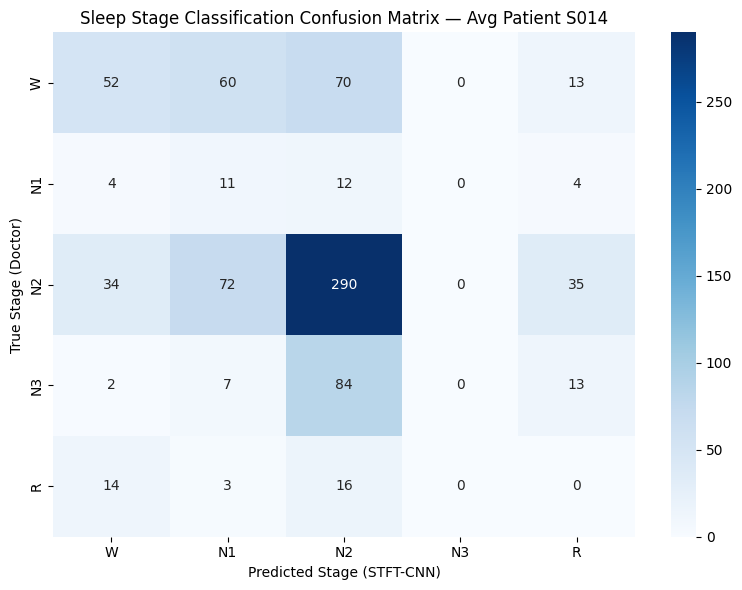

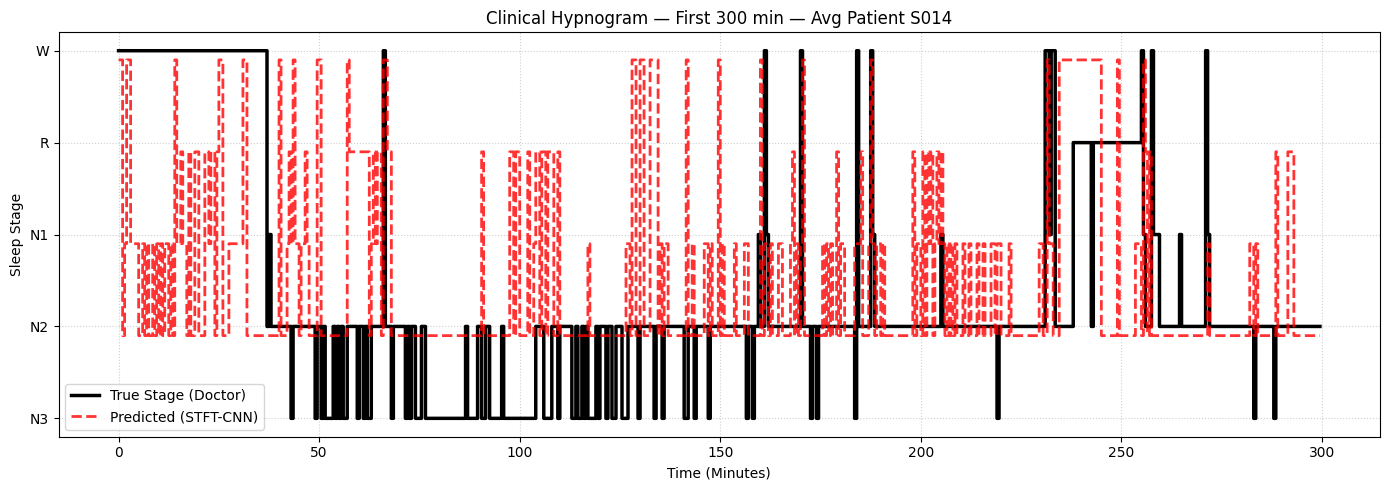

(array([0, 0, 2, 1, 0, 0, 1, 1, 1, 1, 2, 2, 1, 2, 1, 2, 2, 1, 2, 1, 2, 1,
        2, 1, 1, 2, 1, 2, 0, 1, 1, 4, 1, 1, 2, 4, 2, 2, 4, 4, 2, 2, 2, 4,
        4, 1, 4, 4, 2, 4, 0, 0, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 1, 4, 1, 0,
        1, 1, 2, 1, 1, 4, 1, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 1, 4, 1, 4, 4, 2,
        0, 0, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 2,
        4, 4, 2, 2, 2, 2, 4, 2, 2, 1, 4, 4, 2, 4, 4, 2, 4, 4, 4, 2, 2, 4,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 0, 0, 2, 2, 0, 0, 2, 2,
        2, 0, 0, 0, 0, 2, 1, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2,
        1, 2, 2, 2, 2, 2, 1, 1, 2, 1, 

In [25]:
print("=== Test Avg (S014) ===")
evaluate_and_plot(model_6ch, loader_avg_6ch, title_suffix=' — Avg Patient S014')


Test with healthy patient (S049)

=== Test Healthy (S049) ===
Accuracy              : 0.4471
Cohen's Kappa         : 0.0874
Macro-F1 (all 5 cls)  : 0.2078
Macro-F1 (present 4 cls): 0.2597
              precision    recall  f1-score   support

           W       0.27      0.47      0.35       141
          N1       0.01      0.05      0.02        22
          N2       0.75      0.52      0.61       546
          N3       0.00      0.00      0.00         0
           R       0.07      0.06      0.07        85

   micro avg       0.45      0.45      0.45       794
   macro avg       0.22      0.22      0.21       794
weighted avg       0.57      0.45      0.49       794



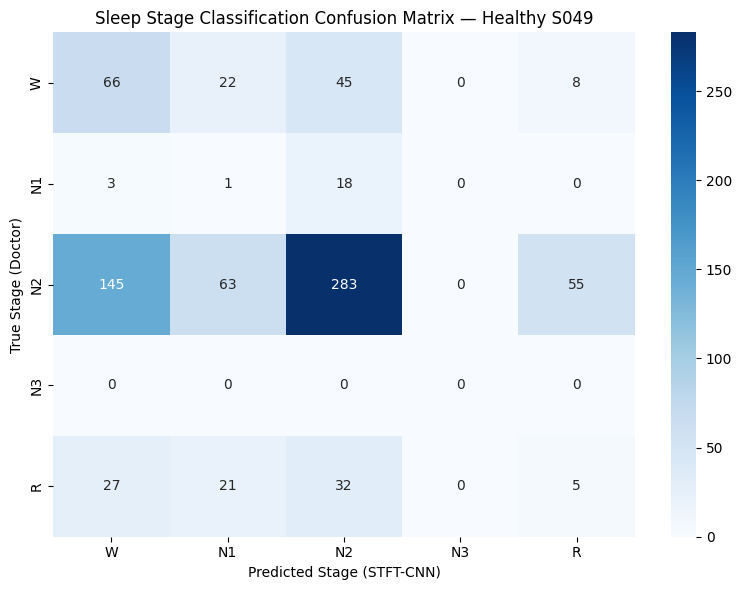

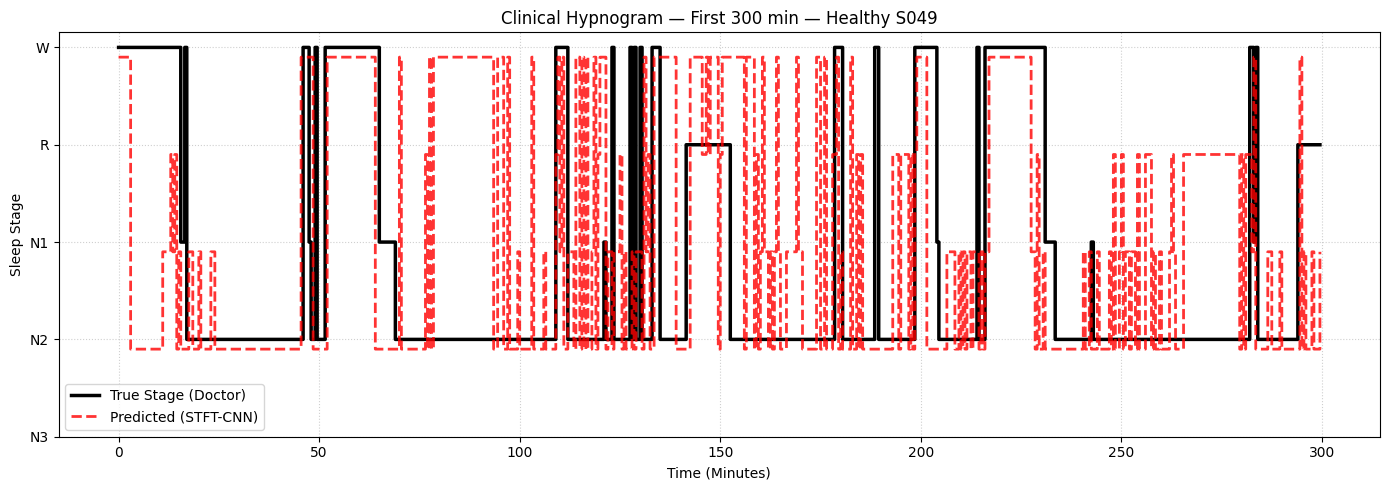

(array([0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        1, 1, 1, 1, 4, 1, 4, 2, 1, 2, 2, 2, 2, 1, 1, 2, 2, 2, 1, 2, 2, 2,
        2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4,
        2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 2,
        2, 1, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 4, 0,
        1, 0, 2, 2, 1, 1, 1, 2, 0, 0, 2, 0, 2, 0, 2, 2, 1, 0, 2, 4, 0, 0,
        0, 2, 1, 1, 2, 1, 1, 1, 4, 2, 1, 2, 2, 2, 1, 2, 1, 1, 1, 2, 0, 1,
        4, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0,
        0, 0, 0, 0, 0, 4, 4, 0, 4, 0, 

In [26]:
print("=== Test Healthy (S049) ===")
evaluate_and_plot(model_6ch, loader_healthy_6ch, title_suffix=' — Healthy S049')


Test with severe patient (S072)

=== Test Severe (S072) ===
Accuracy              : 0.4822
Cohen's Kappa         : 0.2235
Macro-F1 (all 5 cls)  : 0.2587
Macro-F1 (present 3 cls): 0.4311
              precision    recall  f1-score   support

           W       0.85      0.47      0.61       437
          N1       0.26      0.21      0.23       134
          N2       0.33      0.74      0.45       161
          N3       0.00      0.00      0.00         0
           R       0.00      0.00      0.00         0

   micro avg       0.48      0.48      0.48       732
   macro avg       0.29      0.28      0.26       732
weighted avg       0.63      0.48      0.50       732



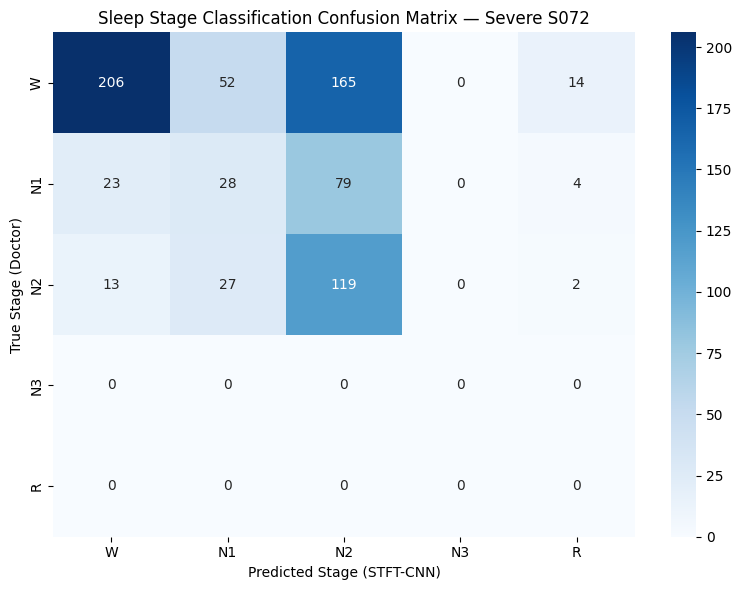

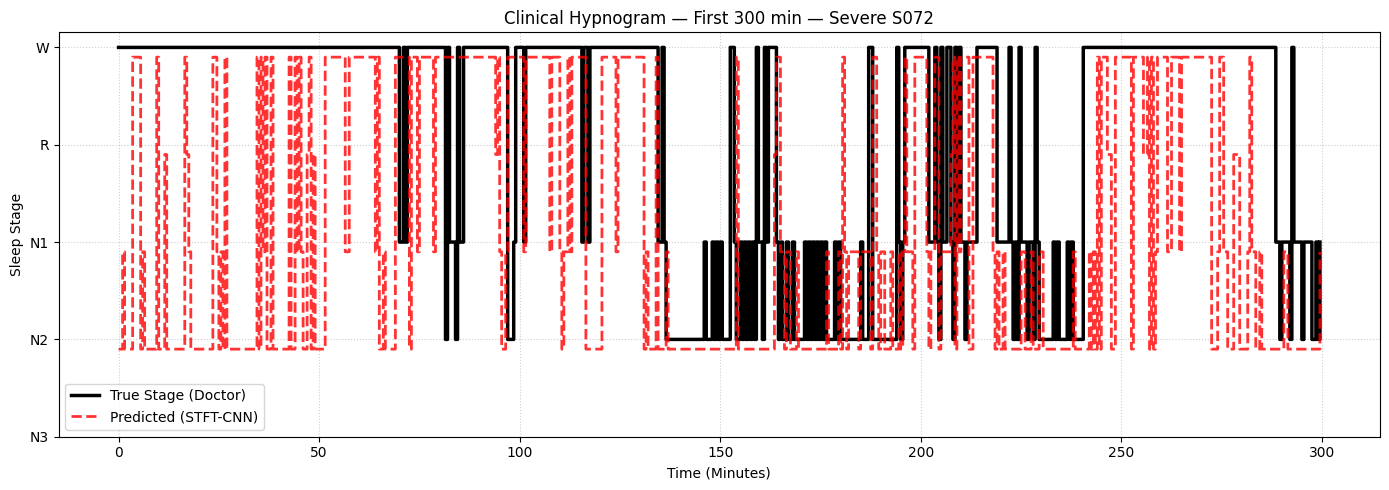

(array([2, 2, 1, 2, 2, 2, 2, 0, 0, 0, 0, 2, 1, 2, 2, 2, 2, 2, 2, 0, 2, 2,
        2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 4, 1, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 0, 0, 1, 2, 1, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 0, 2, 0, 1, 0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2,
        0, 1, 0, 1, 2, 2, 4, 0, 2, 4, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 2,
        1, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 1, 2, 2, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        1, 2, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1,
        2, 2, 2, 2, 0, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

In [27]:
print("=== Test Severe (S072) ===")
evaluate_and_plot(model_6ch, loader_severe_6ch, title_suffix=' — Severe S072')


## Summary — Comparison Table
与 TimesNet 对比用的汇总表

In [28]:
results = {}
for name, loader in [('Avg S014',     loader_avg_6ch),
                     ('Healthy S049', loader_healthy_6ch),
                     ('Severe S072',  loader_severe_6ch)]:
    model_6ch.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            out = model_6ch(X_b.to(DEVICE))
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(y_b.numpy())
    preds, trues = np.array(preds), np.array(trues)
    results[name] = {
        'Accuracy':  round(accuracy_score(trues, preds), 4),
        'Macro-F1':  round(f1_score(trues, preds, average='macro', zero_division=0), 4),
    }

print("\n" + "="*50)
print(f"{'Test Set':<18} {'Accuracy':>10} {'Macro-F1':>10}")
print("-"*40)
for name, r in results.items():
    print(f"{name:<18} {r['Accuracy']:>10.4f} {r['Macro-F1']:>10.4f}")
print("="*50)


Test Set             Accuracy   Macro-F1
----------------------------------------
Avg S014               0.4435     0.2215
Healthy S049           0.4471     0.2597
Severe S072            0.4822     0.3233
